# Step 1: Dataset Acquisition


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/Lumpy Skin Images Dataset - Copy.zip"

Mounted at /content/drive


## Libraries

In [22]:
# 📚 Importing Libraries for Data Handling and Deep Learning

# General-purpose libraries
import os
import glob
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import seaborn as sns
import numpy as np
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt


# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

# 🔥 PyTorch and Vision Modules
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision import datasets, transforms
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import numpy as np
from PIL import Image
from tempfile import TemporaryDirectory
import torch.backends.cudnn as cudnn
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
from tabulate import tabulate
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Enable benchmarking for better performance
cudnn.benchmark = True

# Display plots inline
plt.ion()


## 🔍 Step 2: Data Exploration and Preliminary Analysis

In this step, we will visually inspect the dataset and evaluate:

- 🖼️ **Image size consistency** → to ensure uniformity in input dimensions.
- 🎨 **Data augmentation necessity** → to assess whether augmentation would improve generalization.
- ⚖️ **Class imbalance** → to check if some classes dominate the dataset.
- 📊 **Sample visualization** → to get an idea of image quality and labeling.


In [3]:
dataset_directory = "/content/Lumpy Skin Images Dataset - Copy"

# Get list of class folders
class_names = [folder for folder in os.listdir(dataset_directory) if os.path.isdir(os.path.join(dataset_directory, folder))]

print(f"✅ Dataset directory loaded: {dataset_directory}")
print(f"📂 Found {len(class_names)} classes:\n{class_names}")


✅ Dataset directory loaded: /content/Lumpy Skin Images Dataset - Copy
📂 Found 2 classes:
['Lumpy Skin', 'Normal Skin']


In [4]:
# 📊 Function to compute number of images per class in the dataset
def get_class_image_distribution(data_path):
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.gif', '*.tif', '*.tiff']
    summary = []

    for class_name in os.listdir(data_path):
        class_dir = os.path.join(data_path, class_name)
        if os.path.isdir(class_dir):
            image_files = []
            for ext in image_extensions:
                image_files.extend(glob.glob(os.path.join(class_dir, ext)))
            summary.append({'Class': class_name, 'Image_Count': len(image_files)})

    return pd.DataFrame(summary).sort_values(by="Image_Count", ascending=False).reset_index(drop=True)

# 📁 Specify your dataset directory
dataset_directory = "/content/Lumpy Skin Images Dataset - Copy"

# 📋 Generate image count summary
image_distribution = get_class_image_distribution(dataset_directory)

# ✅ Display the results
print(image_distribution)


         Class  Image_Count
0  Normal Skin         3215
1   Lumpy Skin         2743


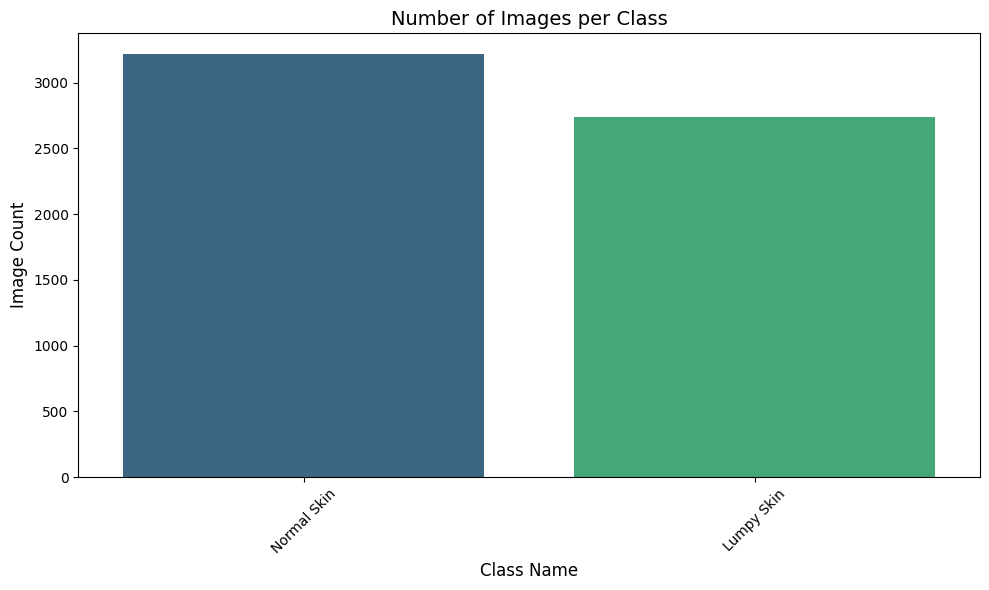

In [7]:
# 📊 Visualize Class Distribution

plt.figure(figsize=(10, 6))
sns.barplot(data=image_distribution, x="Class", y="Image_Count", palette="viridis")

plt.title("Number of Images per Class", fontsize=14)
plt.xlabel("Class Name", fontsize=12)
plt.ylabel("Image Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analyzing image sizes:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Top Image Sizes:
     Image_Size  Count
0  (1920, 1080)   1764
1   (1280, 720)   1599
2    (256, 256)   1113
3    (275, 183)    194
4    (416, 416)    169


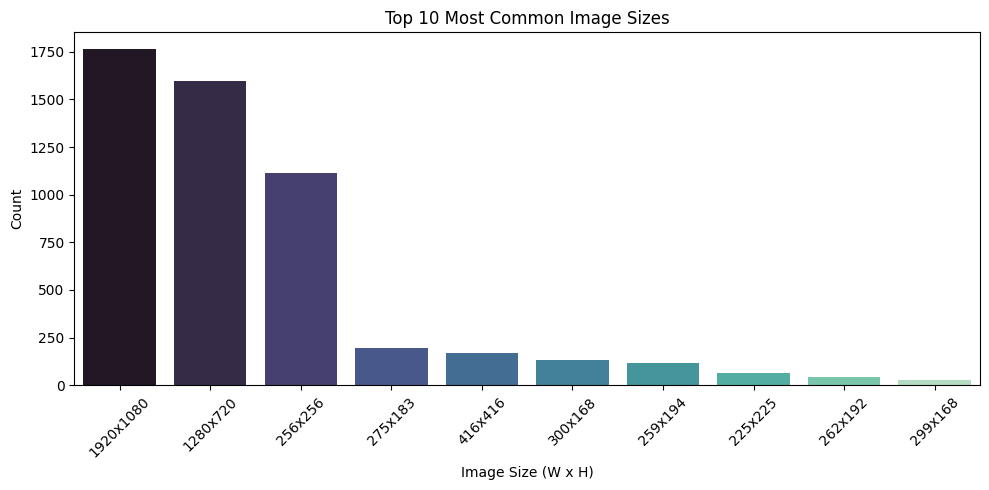

⚠️ Detected high variation in image sizes. Consider resizing during preprocessing.


In [10]:
# 🔍 Function to analyze image dimension consistency
def analyze_image_dimensions(base_path, prediction_mode=False):
    dimensions = []

    # If in prediction mode, look directly into root folder
    folders = [""] if prediction_mode else os.listdir(base_path)

    for folder in tqdm(folders, desc="Analyzing image sizes"):
        folder_path = os.path.join(base_path, folder)
        if os.path.isdir(folder_path) or prediction_mode:
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tif'):
                for img_path in glob.glob(os.path.join(folder_path, ext)):
                    try:
                        with Image.open(img_path) as img:
                            dimensions.append(img.size)  # (width, height)
                    except:
                        continue

    # Return result as a sorted DataFrame
    return pd.Series(dimensions).value_counts().reset_index(name="Count").rename(columns={"index": "Image_Size"})

# 📏 Run analysis on dataset
dataset_directory = "/content/Lumpy Skin Images Dataset - Copy"
image_size_summary = analyze_image_dimensions(dataset_directory)

# 🖼️ Display top sizes
print("🔍 Top Image Sizes:")
print(image_size_summary.head())

# ✅ Convert image sizes to string format for plotting
image_size_summary["Image_Size_Str"] = image_size_summary["Image_Size"].apply(lambda x: f"{x[0]}x{x[1]}")

# 📊 Plot top 10 most common image sizes
plt.figure(figsize=(10, 5))
sns.barplot(data=image_size_summary.head(10), x="Image_Size_Str", y="Count", palette="mako")
plt.title("Top 10 Most Common Image Sizes")
plt.xlabel("Image Size (W x H)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ⚠️ Warn if too much variation exists
if len(image_size_summary) > 3:
    print("⚠️ Detected high variation in image sizes. Consider resizing during preprocessing.")


# 🛠️ Step 3: Define Image Transformations for Training and Testing

In [11]:
# Define desired input size for the model
input_image_size = 224

# 📦 Training transformations (with light augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((input_image_size, input_image_size)),   # Resize to uniform size
    transforms.RandomHorizontalFlip(p=0.5),                     # Augmentation: horizontal flip
    transforms.ToTensor(),                                      # Convert image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],            # Normalize using ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# 🧪 Testing/Validation transformations (no augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((input_image_size, input_image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


#  📁 STEP 4 : Dataset Partitioning and Loading
#   → Divide the dataset into training, validation, and test subsets
#   → Set up DataLoaders for efficient batch processing


In [12]:
# 📁 Load the full image dataset with training transformations applied
dataset = datasets.ImageFolder(root=dataset_directory, transform=train_transforms)

In [13]:
# 🏷️ Retrieve class labels from the dataset (based on folder names)
class_names = dataset.classes
print("Available Classes:", class_names)

Available Classes: ['Lumpy Skin', 'Normal Skin']


# 🧠 Step 5: Load and Customize a Pre-trained CNN
#   - Import a pre-trained model
#   - Adapt the classifier head for our number of classes
#   - Display model structure
#   - Define the loss function


In [17]:
# ⚙️ Training Configuration
#   - Define number of output classes
#   - Set number of epochs and learning rate

num_classes = 2
num_epochs = 10
learning_rate = 2e-5  # Equivalent to 0.00002


In [16]:
# 🧠 Load and Modify Pre-trained EfficientNet-B0
#   - Load model with ImageNet weights
#   - Replace final classification layer to match our number of classes

model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 174MB/s]


In [18]:
# 🚀 Move Model to Available Device (GPU if available, else CPU)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [19]:
# 🧪 Optimizer and Learning Rate Scheduler
#   - Use Adam optimizer with defined learning rate
#   - Apply StepLR scheduler to reduce LR every 5 epochs

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


In [20]:
# 📊 Model Summary
#   - Display detailed architecture of the model
#   - Includes output shapes and number of parameters

from torchsummary import summary
summary(model, (3, 224, 224))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

# 🔁 Step 6: Training & Validation Loop
#   - Perform training on the training dataset
#   - Evaluate model performance on the validation set after each epoch


In [21]:
# 📦 Dataset Splitting (Train/Test)
#   - Define desired split ratios
#   - Randomly split the dataset into training and testing sets

train_ratio = 0.8
test_ratio = 0.2

# 📏 Compute split sizes
dataset_size = len(dataset)
train_size = int(train_ratio * dataset_size)
test_size = dataset_size - train_size

# 🔀 Perform the split
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# 📊 Display the size of each split
print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")


Training set size: 4766
Test set size: 1192



======== Fold 0 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.1743 │
├───────────┼─────────┤
│ Accuracy  │  0.935  │
├───────────┼─────────┤
│ Precision │  0.9354 │
├───────────┼─────────┤
│ Recall    │  0.9336 │
├───────────┼─────────┤
│ F1 Score  │  0.9344 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.1194 │
├───────────┼─────────┤
│ Accuracy  │  0.958  │
├───────────┼─────────┤
│ Precision │  0.9582 │
├───────────┼─────────┤
│ Recall    │  0.9573 │
├───────────┼─────────┤
│ F1 Score  │  0.9577 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.1002 │
├───────────┼─────────┤
│ Accuracy  │  0.9618 │
├───────────┼─────────┤
│ Precision │  0.9616 │
├───────────┼─────────┤
│ Recall    │  0.9615 │
├───────────┼─────────┤
│ F1 Score  │  0.9616 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0759 │
├───────────┼─────────┤
│ Accuracy  │  0.9704 │
├───────────┼─────────┤
│ Precision │  0.9707 │
├───────────┼─────────┤
│ Recall    │  0.9697 │
├───────────┼─────────┤
│ F1 Score  │  0.9702 │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.038  │
├───────────┼─────────┤
│ Accuracy  │  0.9862 │
├───────────┼─────────┤
│ Precision │  0.9862 │
├───────────┼─────────┤
│ Recall    │  0.986  │
├───────────┼─────────┤
│ F1 Score  │  0.9861 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0216 │
├───────────┼─────────┤
│ Accuracy  │  0.9929 │
├───────────┼─────────┤
│ Precision │  0.9929 │
├───────────┼─────────┤
│ Recall    │  0.9928 │
├───────────┼─────────┤
│ F1 Score  │  0.9928 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.018  │
├───────────┼─────────┤
│ Accuracy  │  0.9935 │
├───────────┼─────────┤
│ Precision │  0.9934 │
├───────────┼─────────┤
│ Recall    │  0.9935 │
├───────────┼─────────┤
│ F1 Score  │  0.9935 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0286 │
├───────────┼─────────┤
│ Accuracy  │  0.9903 │
├───────────┼─────────┤
│ Precision │  0.9903 │
├───────────┼─────────┤
│ Recall    │  0.9903 │
├───────────┼─────────┤
│ F1 Score  │  0.9903 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.014  │
├───────────┼─────────┤
│ Accuracy  │  0.995  │
├───────────┼─────────┤
│ Precision │  0.9949 │
├───────────┼─────────┤
│ Recall    │  0.995  │
├───────────┼─────────┤
│ F1 Score  │  0.9949 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.1574 │
├───────────┼────────┤
│ Accuracy  │ 0.9631 │
├───────────┼────────┤
│ Precision │ 0.9629 │
├───────────┼────────┤
│ Recall    │ 0.9629 │
├───────────┼────────┤
│ F1 Score  │ 0.9629 │
╘═══════════╧════════╛

Classification Report:
              precision    recall  f1-score   support

  Lumpy Skin       0.96      0.96      0.96       552
 Normal Skin       0.97      0.97      0.97       640

    accuracy                           0.96      1192
   macro avg       0.96      0.96      0.96      1192
weighted avg       0.96      0.96      0.96      1192



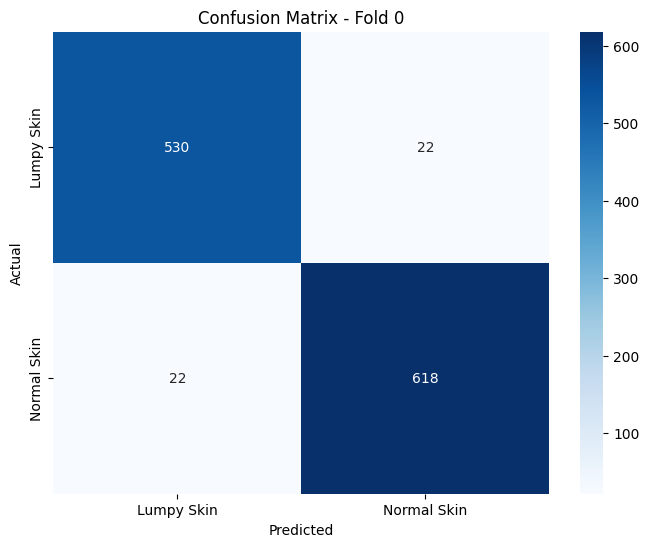


======== Fold 1 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0756 │
├───────────┼─────────┤
│ Accuracy  │  0.9767 │
├───────────┼─────────┤
│ Precision │  0.9766 │
├───────────┼─────────┤
│ Recall    │  0.9767 │
├───────────┼─────────┤
│ F1 Score  │  0.9766 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0515 │
├───────────┼─────────┤
│ Accuracy  │  0.9817 │
├───────────┼─────────┤
│ Precision │  0.9816 │
├───────────┼─────────┤
│ Recall    │  0.9817 │
├───────────┼─────────┤
│ F1 Score  │  0.9817 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0552 │
├───────────┼─────────┤
│ Accuracy  │  0.982  │
├───────────┼─────────┤
│ Precision │  0.9818 │
├───────────┼─────────┤
│ Recall    │  0.982  │
├───────────┼─────────┤
│ F1 Score  │  0.9819 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0364 │
├───────────┼─────────┤
│ Accuracy  │  0.988  │
├───────────┼─────────┤
│ Precision │  0.9881 │
├───────────┼─────────┤
│ Recall    │  0.9879 │
├───────────┼─────────┤
│ F1 Score  │  0.988  │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0153 │
├───────────┼─────────┤
│ Accuracy  │  0.995  │
├───────────┼─────────┤
│ Precision │  0.995  │
├───────────┼─────────┤
│ Recall    │  0.9949 │
├───────────┼─────────┤
│ F1 Score  │  0.9949 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0108 │
├───────────┼─────────┤
│ Accuracy  │  0.996  │
├───────────┼─────────┤
│ Precision │  0.996  │
├───────────┼─────────┤
│ Recall    │  0.996  │
├───────────┼─────────┤
│ F1 Score  │  0.996  │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0125 │
├───────────┼─────────┤
│ Accuracy  │  0.9956 │
├───────────┼─────────┤
│ Precision │  0.9955 │
├───────────┼─────────┤
│ Recall    │  0.9956 │
├───────────┼─────────┤
│ F1 Score  │  0.9956 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0145 │
├───────────┼─────────┤
│ Accuracy  │  0.9943 │
├───────────┼─────────┤
│ Precision │  0.9944 │
├───────────┼─────────┤
│ Recall    │  0.9942 │
├───────────┼─────────┤
│ F1 Score  │  0.9943 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0086 │
├───────────┼─────────┤
│ Accuracy  │  0.996  │
├───────────┼─────────┤
│ Precision │  0.9959 │
├───────────┼─────────┤
│ Recall    │  0.9961 │
├───────────┼─────────┤
│ F1 Score  │  0.996  │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0505 │
├───────────┼────────┤
│ Accuracy  │ 0.9874 │
├───────────┼────────┤
│ Precision │ 0.987  │
├───────────┼────────┤
│ Recall    │ 0.9873 │
├───────────┼────────┤
│ F1 Score  │ 0.9872 │
╘═══════════╧════════╛

Classification Report:
              precision    recall  f1-score   support

  Lumpy Skin       0.98      0.99      0.99       512
 Normal Skin       0.99      0.99      0.99       680

    accuracy                           0.99      1192
   macro avg       0.99      0.99      0.99      1192
weighted avg       0.99      0.99      0.99      1192



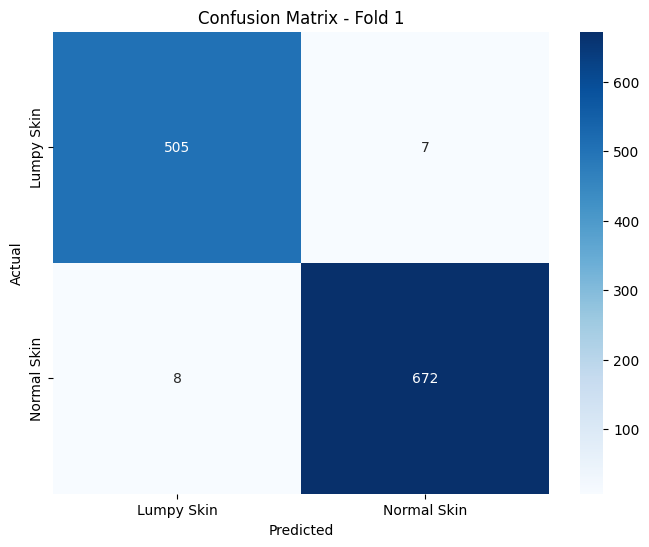


======== Fold 2 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0453 │
├───────────┼─────────┤
│ Accuracy  │  0.9843 │
├───────────┼─────────┤
│ Precision │  0.9841 │
├───────────┼─────────┤
│ Recall    │  0.9842 │
├───────────┼─────────┤
│ F1 Score  │  0.9841 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.042  │
├───────────┼─────────┤
│ Accuracy  │  0.9849 │
├───────────┼─────────┤
│ Precision │  0.9846 │
├───────────┼─────────┤
│ Recall    │  0.985  │
├───────────┼─────────┤
│ F1 Score  │  0.9848 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0295 │
├───────────┼─────────┤
│ Accuracy  │  0.9893 │
├───────────┼─────────┤
│ Precision │  0.9892 │
├───────────┼─────────┤
│ Recall    │  0.9893 │
├───────────┼─────────┤
│ F1 Score  │  0.9892 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0355 │
├───────────┼─────────┤
│ Accuracy  │  0.9876 │
├───────────┼─────────┤
│ Precision │  0.9875 │
├───────────┼─────────┤
│ Recall    │  0.9875 │
├───────────┼─────────┤
│ F1 Score  │  0.9875 │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0159 │
├───────────┼─────────┤
│ Accuracy  │  0.9929 │
├───────────┼─────────┤
│ Precision │  0.9927 │
├───────────┼─────────┤
│ Recall    │  0.9929 │
├───────────┼─────────┤
│ F1 Score  │  0.9928 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0067 │
├───────────┼─────────┤
│ Accuracy  │  0.9973 │
├───────────┼─────────┤
│ Precision │  0.9972 │
├───────────┼─────────┤
│ Recall    │  0.9973 │
├───────────┼─────────┤
│ F1 Score  │  0.9973 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0099 │
├───────────┼─────────┤
│ Accuracy  │  0.9966 │
├───────────┼─────────┤
│ Precision │  0.9966 │
├───────────┼─────────┤
│ Recall    │  0.9967 │
├───────────┼─────────┤
│ F1 Score  │  0.9966 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0062 │
├───────────┼─────────┤
│ Accuracy  │  0.9973 │
├───────────┼─────────┤
│ Precision │  0.9972 │
├───────────┼─────────┤
│ Recall    │  0.9973 │
├───────────┼─────────┤
│ F1 Score  │  0.9973 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0074 │
├───────────┼─────────┤
│ Accuracy  │  0.9973 │
├───────────┼─────────┤
│ Precision │  0.9972 │
├───────────┼─────────┤
│ Recall    │  0.9973 │
├───────────┼─────────┤
│ F1 Score  │  0.9973 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.018  │
├───────────┼────────┤
│ Accuracy  │ 0.9941 │
├───────────┼────────┤
│ Precision │ 0.9942 │
├───────────┼────────┤
│ Recall    │ 0.994  │
├───────────┼────────┤
│ F1 Score  │ 0.9941 │
╘═══════════╧════════╛

Classification Report:
              precision    recall  f1-score   support

  Lumpy Skin       1.00      0.99      0.99       573
 Normal Skin       0.99      1.00      0.99       619

    accuracy                           0.99      1192
   macro avg       0.99      0.99      0.99      1192
weighted avg       0.99      0.99      0.99      1192



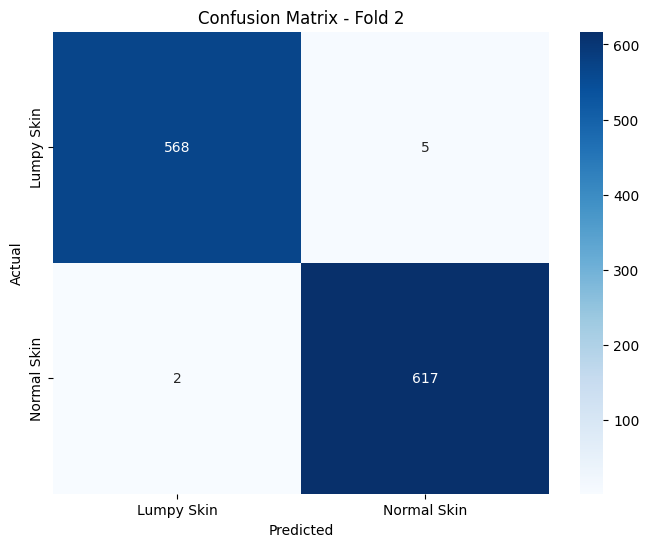


======== Fold 3 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0273 │
├───────────┼─────────┤
│ Accuracy  │  0.991  │
├───────────┼─────────┤
│ Precision │  0.9909 │
├───────────┼─────────┤
│ Recall    │  0.9909 │
├───────────┼─────────┤
│ F1 Score  │  0.9909 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0315 │
├───────────┼─────────┤
│ Accuracy  │  0.9891 │
├───────────┼─────────┤
│ Precision │  0.9891 │
├───────────┼─────────┤
│ Recall    │  0.9889 │
├───────────┼─────────┤
│ F1 Score  │  0.989  │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0272 │
├───────────┼─────────┤
│ Accuracy  │  0.9906 │
├───────────┼─────────┤
│ Precision │  0.9904 │
├───────────┼─────────┤
│ Recall    │  0.9905 │
├───────────┼─────────┤
│ F1 Score  │  0.9905 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0208 │
├───────────┼─────────┤
│ Accuracy  │  0.992  │
├───────────┼─────────┤
│ Precision │  0.9918 │
├───────────┼─────────┤
│ Recall    │  0.9922 │
├───────────┼─────────┤
│ F1 Score  │  0.992  │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0117 │
├───────────┼─────────┤
│ Accuracy  │  0.9956 │
├───────────┼─────────┤
│ Precision │  0.9955 │
├───────────┼─────────┤
│ Recall    │  0.9956 │
├───────────┼─────────┤
│ F1 Score  │  0.9956 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0082 │
├───────────┼─────────┤
│ Accuracy  │  0.9969 │
├───────────┼─────────┤
│ Precision │  0.9968 │
├───────────┼─────────┤
│ Recall    │  0.9969 │
├───────────┼─────────┤
│ F1 Score  │  0.9968 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0058 │
├───────────┼─────────┤
│ Accuracy  │  0.9977 │
├───────────┼─────────┤
│ Precision │  0.9976 │
├───────────┼─────────┤
│ Recall    │  0.9978 │
├───────────┼─────────┤
│ F1 Score  │  0.9977 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0141 │
├───────────┼─────────┤
│ Accuracy  │  0.9956 │
├───────────┼─────────┤
│ Precision │  0.9956 │
├───────────┼─────────┤
│ Recall    │  0.9955 │
├───────────┼─────────┤
│ F1 Score  │  0.9956 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0054 │
├───────────┼─────────┤
│ Accuracy  │  0.9969 │
├───────────┼─────────┤
│ Precision │  0.9967 │
├───────────┼─────────┤
│ Recall    │  0.9969 │
├───────────┼─────────┤
│ F1 Score  │  0.9968 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0171 │
├───────────┼────────┤
│ Accuracy  │ 0.9941 │
├───────────┼────────┤
│ Precision │ 0.9941 │
├───────────┼────────┤
│ Recall    │ 0.9941 │
├───────────┼────────┤
│ F1 Score  │ 0.9941 │
╘═══════════╧════════╛

Classification Report:
              precision    recall  f1-score   support

  Lumpy Skin       0.99      0.99      0.99       572
 Normal Skin       1.00      0.99      0.99       619

    accuracy                           0.99      1191
   macro avg       0.99      0.99      0.99      1191
weighted avg       0.99      0.99      0.99      1191



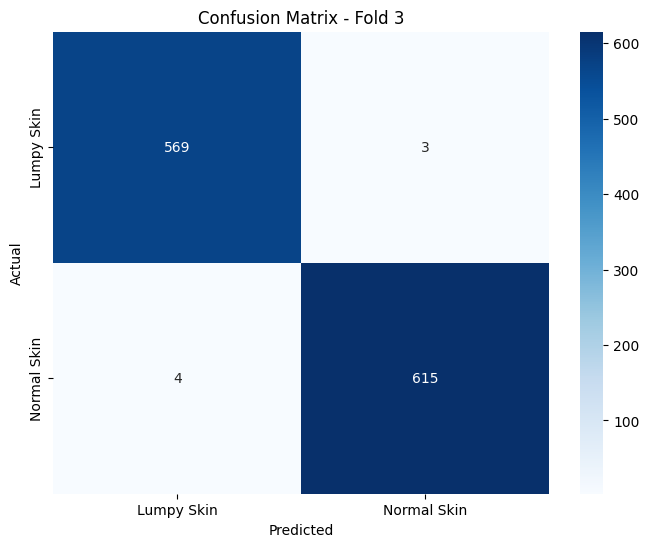


======== Fold 4 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0256 │
├───────────┼─────────┤
│ Accuracy  │  0.9908 │
├───────────┼─────────┤
│ Precision │  0.9907 │
├───────────┼─────────┤
│ Recall    │  0.9908 │
├───────────┼─────────┤
│ F1 Score  │  0.9907 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.025  │
├───────────┼─────────┤
│ Accuracy  │  0.9929 │
├───────────┼─────────┤
│ Precision │  0.9928 │
├───────────┼─────────┤
│ Recall    │  0.9929 │
├───────────┼─────────┤
│ F1 Score  │  0.9928 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0171 │
├───────────┼─────────┤
│ Accuracy  │  0.9948 │
├───────────┼─────────┤
│ Precision │  0.9946 │
├───────────┼─────────┤
│ Recall    │  0.9948 │
├───────────┼─────────┤
│ F1 Score  │  0.9947 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.013  │
├───────────┼─────────┤
│ Accuracy  │  0.9948 │
├───────────┼─────────┤
│ Precision │  0.9947 │
├───────────┼─────────┤
│ Recall    │  0.9947 │
├───────────┼─────────┤
│ F1 Score  │  0.9947 │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0122 │
├───────────┼─────────┤
│ Accuracy  │  0.996  │
├───────────┼─────────┤
│ Precision │  0.996  │
├───────────┼─────────┤
│ Recall    │  0.996  │
├───────────┼─────────┤
│ F1 Score  │  0.996  │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0073 │
├───────────┼─────────┤
│ Accuracy  │  0.9975 │
├───────────┼─────────┤
│ Precision │  0.9974 │
├───────────┼─────────┤
│ Recall    │  0.9975 │
├───────────┼─────────┤
│ F1 Score  │  0.9975 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0057 │
├───────────┼─────────┤
│ Accuracy  │  0.9977 │
├───────────┼─────────┤
│ Precision │  0.9976 │
├───────────┼─────────┤
│ Recall    │  0.9977 │
├───────────┼─────────┤
│ F1 Score  │  0.9977 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0059 │
├───────────┼─────────┤
│ Accuracy  │  0.9975 │
├───────────┼─────────┤
│ Precision │  0.9975 │
├───────────┼─────────┤
│ Recall    │  0.9975 │
├───────────┼─────────┤
│ F1 Score  │  0.9975 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0075 │
├───────────┼─────────┤
│ Accuracy  │  0.9973 │
├───────────┼─────────┤
│ Precision │  0.9972 │
├───────────┼─────────┤
│ Recall    │  0.9973 │
├───────────┼─────────┤
│ F1 Score  │  0.9973 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0133 │
├───────────┼────────┤
│ Accuracy  │ 0.9958 │
├───────────┼────────┤
│ Precision │ 0.9957 │
├───────────┼────────┤
│ Recall    │ 0.9958 │
├───────────┼────────┤
│ F1 Score  │ 0.9958 │
╘═══════════╧════════╛

Classification Report:
              precision    recall  f1-score   support

  Lumpy Skin       0.99      1.00      1.00       534
 Normal Skin       1.00      1.00      1.00       657

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191



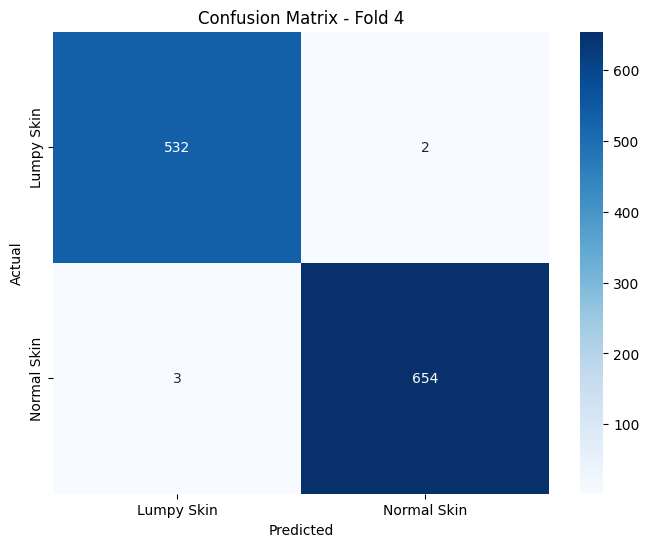


======= K-FOLD CROSS VALIDATION RESULTS =======
Fold 0: 96.31%
Fold 1: 98.74%
Fold 2: 99.41%
Fold 3: 99.41%
Fold 4: 99.58%

Average Accuracy: 98.69%


In [23]:
#  ====== Class Weight Calculation ======
def compute_class_weights_from_loader(dataloader, num_classes, device):
    class_counts = Counter()
    for _, labels in dataloader:
        class_counts.update(labels.cpu().numpy())
    total_samples = sum(class_counts.values())
    weights = [1.0 / class_counts[i] if i in class_counts else 0 for i in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float, device=device)

# ⚙️ ====== Hyperparameters & K-Fold Setup ======
batch_size = 32
splits = 5
num_epochs = 10

# 🧹 Merge train and test sets for K-Fold
dataset = ConcatDataset([train_dataset, test_dataset])

# 🔀 Prepare K-Fold cross-validation
kfold = KFold(n_splits=splits, shuffle=True)
results = {}

# 🔁 ====== K-Fold Training Loop ======
for fold, (train_idx, test_idx) in enumerate(kfold.split(dataset)):
    print(f'\n======== Fold {fold} ========')

    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

    # 📊 Compute class weights for the current fold
    class_weights = compute_class_weights_from_loader(train_loader, num_classes=len(class_names), device=device)

    # 🔧 Model, Loss, Optimizer, Scheduler setup
    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # 📈 ====== Training Phase ======
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        model.train()

        total_train_loss = 0
        correct_train = 0
        total_train = 0
        y_true_train, y_pred_train = [], []

        loop = tqdm(train_loader, desc=f"Training Fold {fold}", leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())
            loop.set_postfix(loss=loss.item())

        scheduler.step()

        # 🧮 Compute training metrics
        train_loss = total_train_loss / total_train
        train_acc = correct_train / total_train
        train_precision = precision_score(y_true_train, y_pred_train, average='macro')
        train_recall = recall_score(y_true_train, y_pred_train, average='macro')
        train_f1 = f1_score(y_true_train, y_pred_train, average='macro')

        # 📋 Print training metrics
        print(tabulate([
            ["Loss", f"{train_loss:.4f}"],
            ["Accuracy", f"{train_acc:.4f}"],
            ["Precision", f"{train_precision:.4f}"],
            ["Recall", f"{train_recall:.4f}"],
            ["F1 Score", f"{train_f1:.4f}"],
        ], headers=["Metric", "Train"], tablefmt="fancy_grid"))

    # 🔍 ====== Evaluation on Test Set ======
    print("\nEvaluating on test set...")
    model.eval()
    test_loss = 0
    correct_test = 0
    total_test = 0
    y_true_test, y_pred_test = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(preds.cpu().numpy())

    # 📊 Compute test metrics
    acc = correct_test / total_test
    prec = precision_score(y_true_test, y_pred_test, average='macro')
    rec = recall_score(y_true_test, y_pred_test, average='macro')
    f1 = f1_score(y_true_test, y_pred_test, average='macro')

    results[fold] = acc

    # 🧾 Display test results
    print(tabulate([
        ["Loss", f"{test_loss / total_test:.4f}"],
        ["Accuracy", f"{acc:.4f}"],
        ["Precision", f"{prec:.4f}"],
        ["Recall", f"{rec:.4f}"],
        ["F1 Score", f"{f1:.4f}"],
    ], headers=["Metric", "Test"], tablefmt="fancy_grid"))

    # 📁 Detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_true_test, y_pred_test, target_names=class_names))

    # 📌 Confusion matrix visualization
    cm = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.show()

    # 📂 Save the model checkpoint for this fold
    torch.save(model.state_dict(), f'./model_fold_{fold}.pth')

# 🏁 Final aggregated K-Fold results
print("\n======= K-FOLD CROSS VALIDATION RESULTS =======")
avg_acc = 0
for fold, acc in results.items():
    print(f"Fold {fold}: {acc * 100:.2f}%")
    avg_acc += acc
print(f"\nAverage Accuracy: {(avg_acc / splits) * 100:.2f}%")


# 🔮 Step 7: Make Predictions & Visualize Results



In [24]:
# 🖼️ Display Single Image with Label (Denormalized)
def show_single_prediction(img, label):
    """
    Visualizes a single image after denormalization.

    Args:
        img (torch.Tensor): Image tensor with shape (C, H, W), normalized.
        label (str): Class label to be shown as the title.
    """
    # Convert tensor to NumPy and adjust channels
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))  # Convert (C, H, W) to (H, W, C)

    # Reverse normalization (ImageNet)
    npimg = npimg * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    npimg = np.clip(npimg, 0, 1)

    plt.imshow(npimg)
    plt.title(label)
    plt.axis('off')
    plt.show()


In [25]:
# 🧪🔍 Visualize Predictions on Test Images (in Grid)
def plot_model_predictions_grid(model, test_loader, class_names, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Displays a grid of test images with predicted and true labels.

    Args:
        model (torch.nn.Module): Trained model used for inference.
        test_loader (DataLoader): DataLoader for the test set.
        class_names (list): List of class names (e.g., ['Healthy', 'Lumpy']).
        device (str): Device to run inference on ('cuda' or 'cpu').
    """
    was_training = model.training
    model.eval()
    model.to(device)

    fig, axs = plt.subplots(nrows=4, ncols=9, figsize=(16, 9))  # Adjust grid size as needed
    axs = axs.flatten()

    index = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()

            for i in range(images.shape[0]):
                if index >= len(axs):
                    break

                npimg = images[i].permute(1, 2, 0).numpy()

                # Reverse normalization
                npimg = npimg * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                npimg = np.clip(npimg, 0, 1)

                axs[index].imshow(npimg)
                axs[index].axis("off")

                pred_label = class_names[preds[i].item()]
                true_label = class_names[labels[i].item()]
                title_text = f"Pred: {pred_label}\nTrue: {true_label}".title()

                # Title color: green if correct, red if incorrect
                title_color = "green" if pred_label == true_label else "red"
                axs[index].set_title(title_text, fontsize=10, color=title_color)

                index += 1

            if index >= len(axs):
                break

    plt.tight_layout()
    plt.show()
    model.train(mode=was_training)


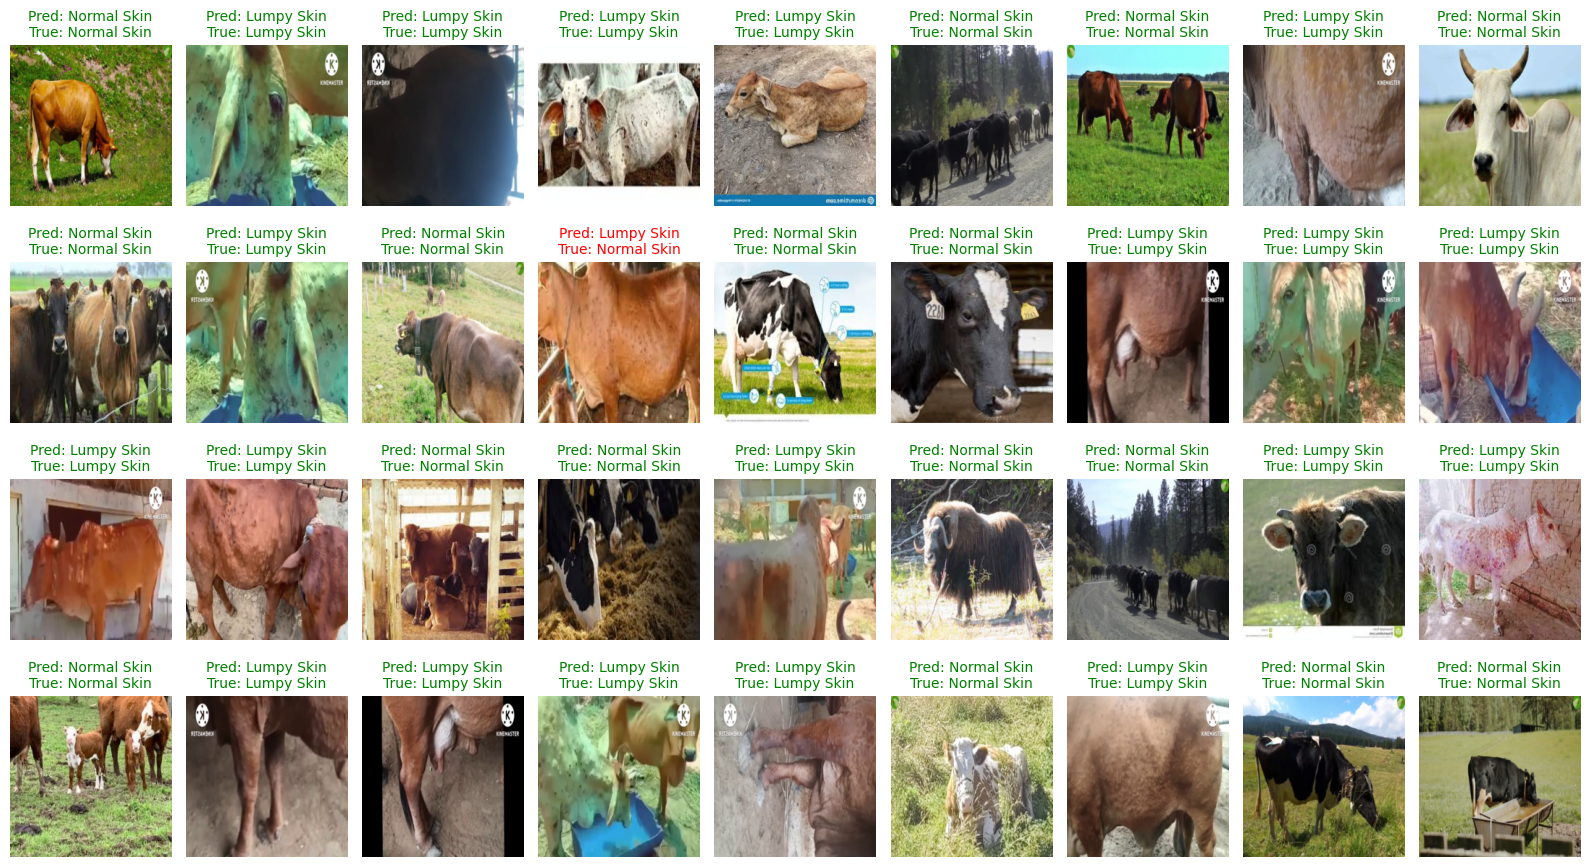

In [26]:
# 🏷️ Define class names based on your dataset
class_names = ['Lumpy Skin', 'Normal Skin']  # Adjust if needed

# 📊 Visualize model predictions on test images
plot_model_predictions_grid(model, test_loader, class_names)

# 🔒 Ensure plots are rendered correctly before the notebook ends
plt.ioff()
plt.show()
